## Libraries & Function

In [1]:
%matplotlib ipympl
import numpy as np
from scipy.linalg import expm
from qutip import *
import numba
from numba import njit, prange
import matplotlib.pyplot as plt
from IPython.display import Image, display, Math


In [2]:

sz = np.array(([[1,0], [0,-1]]), dtype=complex); sx = np.array(([[0,1],[1,0]]), dtype=complex); sy = np.array(([[0,-1j],[1j,0]]), dtype=complex) 


In [3]:
#funzione per plottare in LaTex delle matrici
def array_to_latex(array, real = False, array_name = None):
    array = array.real if real else array
    matrix = ''
    for row in array:
        try:
            for number in row:
                matrix += f'{number}&'
        except TypeError:
            matrix += f'{row}&'
        matrix = matrix[:-1] + r'\\'
    if array_name != None:
        display(Math(array_name+r' = \begin{bmatrix}'+matrix+r'\end{bmatrix}'))
    else:
        display(Math(r'\begin{bmatrix}'+matrix+r'\end{bmatrix}'))

### Hamiltonians and U operator

In [4]:
def system_Hamiltonian(N_site, E, V_array, mode="complete"):
    """
    Build up of the System's Hamiltonian for the complete basis (ground & excited states) or only excited states.
    
    Method: - "complete"-> complete basis (ground & excited states)
            - "exc"-> excited basis (only excited states)
    
    Parameters: - E: Float, System's Site Energies (randomly generated)
                - V_array: Float, Hopping Potential
                - N_site : Int, Number of Sites
        
    Returns : System's Hamiltonian as Numpy array
    """
    # -----------------------------------------------------
    # Build symmetric matrix from upper triangular elements
    # -----------------------------------------------------
    V_matrix = np.zeros((N_site, N_site))
    idx = 0  # runs over V_array
    for i in range(N_site):
        for j in range(i+1, N_site):
            V_matrix[i, j] = V_array[idx]
            V_matrix[j, i] = V_array[idx]  # Symmetric
            idx += 1
    
    # -------------------------
    # Only Excited States Basis
    # -------------------------
    if mode == "exc":   
        H_sys = np.zeros((N_site, N_site), dtype=complex)
        for i in range(N_site):
            H_sys[i, i] = E[i]
 
        for i in range(N_site):
            for j in range(N_site):
                if i != j:
                    H_sys[i, j] = V_matrix[i, j]
        return H_sys
        
    # --------------
    # Complete Basis 
    # --------------    
    elif mode == "complete":   
        H_sys = np.zeros((2**N_site, 2**N_site), dtype='complex')
        
        for i in range(N_site):
            H_i = (E[i]/2) * (tensor(identity(2**i), identity(2)-sigmaz(), identity(2**(N_site-i-1))))
            H_sys += H_i.full()
            
            for j in range(i+1, N_site):
               H_ij = V_matrix[i, j]/2 * (tensor(identity(2**i), sigmax(), identity(2**(j-i-1)), sigmax(), identity(2**(N_site-j-1))) + tensor(identity(2**i), sigmay(), identity(2**(j-i-1)), sigmay(), identity(2**(N_site-j-1))))
               H_sys += H_ij.full()
        
        return H_sys

    else:
        raise ValueError("mode : 'complete' or 'exc'")

### Coherent Regime

In [5]:
def interaction_Hamiltonian_Cohe(N_site, c_CM, g_x, g_z):   
    """
    Build up of the Hamiltonian of Interaction for the Collision System - Ancilla in both Quantum Jump and Diffusive Limit
       
    Parameters: - N_site : int, Number of Sites
                - c_CM : list, Interaction Forces for the System - Ancilla intercation/collsion
                - g_x : float, parametr for the sigma x interaction
                - g_z : float, parametr for the sigma z interaction
        
    Returns : Hamiltonian of Interaction as Qutip object
    """
    dim_tot = 2**(2 * N_site)
    H_int = np.zeros((dim_tot, dim_tot), dtype=complex)   #inizialization

    for j in range(N_site):
        # Create fresh lists for Z and X terms
        op_list_z = [qeye(2) for _ in range(2 * N_site)]
        op_list_x = [qeye(2) for _ in range(2 * N_site)]  
        
       # Z_sys tensor Z_anc
        op_list_z[j] = sigmaz()             # System j
        op_list_z[N_site + j] = sigmaz()    # Ancilla j
        
        # Z_sys tensor X_anc
        op_list_x[j] = sigmaz()             # System j
        op_list_x[N_site + j] = sigmax()    # Ancilla j 

        # Tensor product between the element of the list
        term_z = tensor(op_list_z)
        term_x = tensor(op_list_x)
        
        H_term = c_CM[j] * (g_z * term_z + g_x * term_x)  
            
        H_int += H_term.full()
    
    return H_int


In [6]:
def hamiltonian_N_ancillas_Cohe(N_site, E, V_array, c_CM, g_x, g_z):
    """
    Generation of 3 Hamiltonians for the collision model with N ancillas:
                - H_system : system Hamiltonian
                - H_collision : interaction Hamiltonian with N ancillas
                - H_tot : complete Hamiltonian (system + collision)

    Parameters: - E: Float, System's Site Energies (randomly generated)
                - V_array: Float, Hopping Potential
                - N_site : int, Number of Sites
                - c_CM : list, Interaction Forces for the System - Ancilla intercation/collsion

    Returns : H_system, H_collision, H_tot
    """
    
    H_collision = interaction_Hamiltonian_Cohe(N_site, c_CM, g_x, g_z) 
    
    H_system = system_Hamiltonian(N_site, E, V_array, mode="complete")
    H_system = H_system.full() if hasattr(H_system, "full") else H_system
        
    dim_anc = 2**N_site
    Id_ancillas = np.eye(dim_anc, dtype=complex)
    H_system_expanded = np.kron(H_system, Id_ancillas)  #expand H_sys in the total space
        
    H_tot = H_system_expanded + H_collision
        
    return H_system, H_collision, H_tot


In [7]:
def evolution_operator_Cohe(H, dt, method='expm', hermitian=True):
    """
    Build up of the evolution operator U = exp(-i H dt) using Expm or analytic diagonalization.
   
    Parameters: - H : Qobj or nparray, System Hamiltonian
                - dt : float, Timestep
    
    Method : - "expm"-> build up of the Matrix Exponential with expm
             - "diagonalization"->  build up of the propagater U as V @(exp(-i W dt))@ V_dag with W eigenvalues and V eigenvector of the Hamiltonian 

    Returns : Evolution Operator U, 
    """
    H = H.full() if hasattr(H, "full") else np.array(H)
    
    # -----------
    # Expm method
    # -----------
    
    if method == 'expm':
        U = expm(-1j * H * dt)
        return U
        
    # ---------------
    # Diagonalization
    # ---------------
    
    elif method == 'diagonalization':
        if hermitian:
            w, V = np.linalg.eigh(H)
            V_inv = V.conj().T
        else:
            w, V = np.linalg.eig(H) 
            V_inv = np.linalg.inv(V)
                
        U_diag = np.diag(np.exp(-1j * w * dt))
        U = V @ U_diag @ V_inv
        return U, U_diag, w, V

    else:
        raise ValueError("method must be 'expm' or 'diagonalization'")


### Diffusive Limit

In [8]:
def interaction_Hamiltonian_Diff(N_site, c_CM, method=None):   
    """
    Build up of the Hamiltonian of Interaction for the Collision System - Ancilla in both Quantum Jump and Diffusive Limit
       
    Parameters: - N_site : int, Number of Sites
                - c_CM : list, Interaction Forces for the System - Ancilla intercation/collsion

    Method: - QJ : Quantum Jump Limit
            - Diff : Diffusive Limit
        
    Returns : Hamiltonian of Interaction as Qutip object
    """
    if method is None:
        method = INTERACTION_LIMIT
        
    dim_tot = 2**(2 * N_site)  # total Hilbert Space System + Ancilla
    H_int = np.zeros((dim_tot, dim_tot), dtype=complex)   #inizialization

    # Selection of the Ancilla's operator
    if method == 'QJ':
        anc_op = sigmax() # Interaction Z (sys) - X (anc) -> gives jumps/flip
    elif method == 'Diff':
        anc_op = sigmaz() # Interaction Z (sys) - Z (anc) -> gives dephasing
    else:
        raise ValueError("Method has to be 'QJ' or 'Diff'")
        
    for j in range(N_site):
  
        op_list = [identity(2) for _ in range(2 * N_site)]  #list of identity to be fill with the operator sigmaz & sigmax; 2N identity, N for the system and N fo the ancillas
            
        op_list[j] = sigmaz()      # Acts on the j site
        op_list[N_site + j] = anc_op  # Acts on the j ancilla, with index N + j
            
        H_term = c_CM[j] * tensor(op_list)  # tensor product between the element of the list
            
        H_int += H_term.full()
    
    return H_int


In [9]:
def hamiltonian_N_ancillas_Diff(N_site, E, V_array, c_CM):
    """
    Generation of 3 Hamiltonians for the collision model with N ancillas:
                - H_system : system Hamiltonian
                - H_collision : interaction Hamiltonian with N ancillas
                - H_tot : complete Hamiltonian (system + collision)

    Parameters: - E: Float, System's Site Energies (randomly generated)
                - V_array: Float, Hopping Potential
                - N_site : int, Number of Sites
                - c_CM : list, Interaction Forces for the System - Ancilla intercation/collsion, for different sites
    
    Returns : H_system, H_collision, H_tot
    """
    
    H_collision = interaction_Hamiltonian_Diff(N_site, c_CM)
    
    H_system = system_Hamiltonian(N_site, E, V_array, mode="complete")
        
    dim_anc = 2**N_site
    Id_ancillas = np.eye(dim_anc, dtype=complex)
    H_system_expanded = np.kron(H_system, Id_ancillas)  #expand H_sys in the total space
        
    H_tot = H_system_expanded + H_collision
        
    return H_system, H_collision, H_tot


In [10]:
def evolution_operator_Diff(H, dt, method='expm', hermitian=True):
    """
    Build up of the evolution operator U = exp(-i H dt) using Expm or analytic diagonalization.
   
    Parameters: - H : Qobj or nparray, System Hamiltonian
                - dt : float, Timestep
    
    Method : - "expm"-> build up of the Matrix Exponential with expm
             - "diagonalization"->  build up of the propagater U as V @(exp(-i W dt))@ V_dag with W eigenvalues and V eigenvector of the Hamiltonian 

    Returns : Evolution Operator U, eigenvalues w and eigenvectors V
    """
    H = H.full() if hasattr(H, "full") else np.array(H)
    
    # -----------
    # Expm method
    # -----------
    
    if method == 'expm':
        U = expm(-1j * H * dt)
        return U
        
    # ---------------
    # Diagonalization
    # ---------------
    
    elif method == 'diagonalization':
        if hermitian:
            w, V = np.linalg.eigh(H)
            V_inv = V.conj().T
        else:
            w, V = np.linalg.eig(H) 
            V_inv = np.linalg.inv(V)
                
        U_diag = np.diag(np.exp(-1j * w * dt))
        U = V @ U_diag @ V_inv
        return U, U_diag, w, V

    else:
        raise ValueError("method must be 'expm' or 'diagonalization'")


### Lindblad functions

In [11]:
def Liouvillian(H, gamma_k, L_k):
    """
    Build the Liouvillian superoperator.
    
    Parameters: - H : nparray, Hamiltonian matrix
                - gamma_k : list, Decay rates
                - L_k : list, Jump Operators
    
    Returns: - super_L : nparray, Liouvillian superoperator
    """    
    I = np.eye(H.shape[0])
    super_L = -1.j * (np.kron(I, H) - np.kron(H.T, I))
    
    for k in range(len(gamma_k)):
        super_L += gamma_k[k] * (np.kron(np.conj(L_k[k]), L_k[k]) - 0.5 * np.kron(I, np.conj(L_k[k]).T @ L_k[k]) - 0.5 * np.kron((np.conj(L_k[k]).T @ L_k[k]).T, I))
    
    return super_L


In [12]:
@njit(cache=True)
def _evolve_expm_core(super_U, rho_vec_initial, n_times):
    """
    Core evolution loop with expm method (Numba JIT)
    """
    rho_size = rho_vec_initial.shape[0]
    rho_vec_list = np.zeros((rho_size, n_times), dtype=np.complex128)
    rho_vec_list[:, 0] = rho_vec_initial
    
    for i in range(1, n_times):
        rho_vec_list[:, i] = super_U @ rho_vec_list[:, i - 1]
    
    return rho_vec_list


@njit(cache=True)
def _evolve_diagonal_core(V, V_inv, U_diag, rho_vec_initial, n_times):
    """
    Core evolution loop with diagonal method (Numba JIT)
    """
    n_states = len(U_diag)
    
    # Initial coefficients in eigenbasis
    coeff = V_inv @ rho_vec_initial
    coeff_list = np.zeros((n_states, n_times), dtype=np.complex128)
    coeff_list[:, 0] = coeff
    
    # Evolution of coefficients
    for i in range(1, n_times):
        coeff_list[:, i] = U_diag * coeff_list[:, i - 1]
    
    # Transform back to original basis
    rho_vec_list = V @ coeff_list
    
    return rho_vec_list


def Lindblad_evo(rho, H, gamma_k, L_k, times, method="expm", vectorized=True):
    """
    Evolution of the density matrix with the Lindblad Eq. (Optimized with Numba)
    
    Method: - "expm" -> propagator = expm(super_L * dt)
            - "diagonal" -> diagonalization of the super-operator
        
    Vectorized: True/False to choose the output format
    
    Parameters: - H : nparray, System Hamiltonian
                - rho : Qobj or nparray, Initial Density Matrix
                - gamma_k : list, List of Decay Rates
                - L_k : list, List of Jump Operators
                - times : array, Time array
        
    Returns : - if vectorized=True → array (N^2, Nt)
              - if vectorized=False → array (Nt, N_site, N_site)
              - if method="diagonal" also returns V, W
    """
    # Convert to NumPy
    L_k = [L.full() if hasattr(L, "full") else np.array(L, dtype=complex) for L in L_k]
    H = H.full() if hasattr(H, "full") else np.array(H, dtype=complex)
    rho = rho.full() if hasattr(rho, "full") else np.array(rho, dtype=complex)
    
    rho_shape = H.shape[0]
    dt = times[1] - times[0]
    n_times = len(times)
    
    # Build Liouvillian
    super_L = Liouvillian(H, gamma_k, L_k)
    
    # Vectorize initial state
    rho_vec = rho.reshape(rho_shape * rho_shape)
    
    # -------------
    # Expm method
    # -------------
    if method == "expm":
        # Compute propagator 
        super_U = expm(super_L * dt)
        
        # evolution loop
        rho_vec_list = _evolve_expm_core(super_U, rho_vec, n_times)
        
        # Output
        if vectorized:
            return rho_vec_list
        else:
            return rho_vec_list.T.reshape(n_times, rho_shape, rho_shape)
    
    # ------------------
    # Diagonal method
    # ------------------
    elif method == "diagonal":
        # Diagonalize Liouvillian 
        W, V = np.linalg.eig(super_L)
        V_inv = np.linalg.inv(V)
        
        # Diagonal evolution operator
        U_diag = np.exp(W * dt)
        
        # evolution loop
        rho_vec_list = _evolve_diagonal_core(V, V_inv, U_diag, rho_vec, n_times)
        
        # Output
        if vectorized:
            return rho_vec_list, V, W
        else:
            return rho_vec_list.T.reshape(n_times, rho_shape, rho_shape), V, W
    
    else:
        raise ValueError("method must be 'expm' or 'diagonal'")

### Isolated system

In [13]:
@njit(cache=True)
def _compute_trajectory_isolated_core_general(psi_initial, U_site, projectors, n_times):
    """
    Core evolution loop - general for any number of sites
    """
    N_site = projectors.shape[0]
    pop_traj = np.zeros((N_site, n_times), dtype=np.float64)
    
    # Initial populations
    for site in range(N_site):
        P_psi = projectors[site] @ psi_initial
        pop_traj[site, 0] = np.real(np.vdot(psi_initial, P_psi))
    
    # Evolution
    psi = psi_initial.copy()
    for step in range(1, n_times):
        psi = U_site @ psi
        
        for site in range(N_site):
            P_psi = projectors[site] @ psi
            pop_traj[site, step] = np.real(np.vdot(psi, P_psi))
    
    return pop_traj

def compute_trajectory_wf_isolated(N_site, times, projectors, psi_sys_initial, U_site):
    """
    Optimized isolated system evolution with Numba (works for any N_site).
    """
    # Convert to NumPy
    U_site_np = U_site.full() if hasattr(U_site, 'full') else np.array(U_site, dtype=complex)
    psi_initial_np = psi_sys_initial.full() if hasattr(psi_sys_initial, 'full') else np.array(psi_sys_initial, dtype=complex)
    
    # Flatten if needed
    if psi_initial_np.ndim > 1:
        psi_initial_np = psi_initial_np.flatten()

    # Times 
    n_times = len(times)
        
    # JIT-compiled evolution
    pop_traj_isolated = _compute_trajectory_isolated_core_general(
        psi_initial_np, U_site_np, projectors, n_times)
    
    return pop_traj_isolated


## Comparison Diffusive vs Coherent

In [14]:
def generate_comparison_operators(dt, c_j, theta=0.0):
    """
    Generates the Diffusive and Coherent Evolution via single stocastich Trajectories, using the same seed. 
    """
    # --- Intermediate Regime ---
    phi = theta - np.pi/2    # Theta = 0
    
    # Parametri g
    g_z = np.cos(theta)    # 1.0 per theta=0
    g_x = np.sin(theta)    # 0.0 per theta=0
    g_0 = np.cos(phi/2)    #  1/sqrt(2)
    g_1 = np.sin(phi/2)    # -1/sqrt(2)

    # a0, b0 parameters (Eq. 94 LaTeX)
    a0 = g_0 * np.cos(c_j * dt)
    b0 = (g_0 * g_z + g_1 * g_x) * np.sin(c_j * dt)

    # Probability Eq. 98
    P_0_exact = np.abs(a0)**2 + np.abs(b0)**2
    
    # Parenthesis
    par_0 = g_0 * g_z + g_1 * g_x
    par_1 = g_0 * g_x - g_1 * g_z
    
    # Precalculation sin e cos
    cos_c = np.cos(c_j * dt)
    sin_c = np.sin(c_j * dt)
    
    # --- Build up Intermediate Operatos (with correction factor for normalization)---
    norm_factor = 1.0
    if abs(theta) < 1e-6: # i.e. in the diffusive limit
        norm_factor = np.sqrt(2)
        
    # M0_int for outcome '0' 
    M0_int = norm_factor * (g_0 * cos_c * qeye(2) - 1j * par_0 * sin_c * sigmaz())
    # M1_int for outcome '1'
    M1_int = norm_factor * (g_1 * cos_c * qeye(2) - 1j * par_1 * sin_c * sigmaz())

    # Operators with Norm reduction
    M0_raw = (g_0 * cos_c * qeye(2) - 1j * par_0 * sin_c * sigmaz())
    M1_raw = (g_1 * cos_c * qeye(2) - 1j * par_1 * sin_c * sigmaz())
    
    # --- Standard Diffusive Operators ---
    # U0 = cos - i*sin*Sz
    # U1 = cos + i*sin*Sz
    U0_std = cos_c * qeye(2) - 1j * sin_c * sigmaz()
    U1_std = cos_c * qeye(2) + 1j * sin_c * sigmaz()
    
    return M0_int, M1_int, M0_raw, M1_raw, U0_std, U1_std, P_0_exact

# --- Check ---
dt_test = 0.01
c_test = 0.5
m0, m1, _, _, u0, u1, _ = generate_comparison_operators(dt_test, c_test, theta=0.0)

print("Verifica Operatore M0 vs U0 (Diffusivo Standard):")
diff0 = (m0 - u0).norm()
print(f"Differenza Normale: {diff0:.2e}") 

print("\nVerifica Operatore M1 vs U1 (Diffusivo Standard):")
# Nota: Qui ci aspettiamo una differenza di fase globale (-1)
# M1 avrà un segno meno davanti rispetto a U1 perché g_1 è negativo (-1/sqrt(2))
diff1 = (m1 - u1).norm()
diff1_phase = (m1 - (-1)*u1).norm() # Proviamo a flippare il segno
print(f"Differenza Diretta: {diff1:.2f} (Atteso che sia alto per via del segno)")
print(f"Differenza col segno corretto: {diff1_phase:.2e} (Deve essere zero!)")

Verifica Operatore M0 vs U0 (Diffusivo Standard):
Differenza Normale: 0.00e+00

Verifica Operatore M1 vs U1 (Diffusivo Standard):
Differenza Diretta: 4.00 (Atteso che sia alto per via del segno)
Differenza col segno corretto: 0.00e+00 (Deve essere zero!)


## Evolution

In [15]:
@njit
def compute_simultaneous_trajectories(psi_initial, U_site, 
                                      M0s, M1s,          # Intermediate Operators list
                                      U0s, U1s,          # Diffusive Operators list
                                      projectors, n_times, N_site, seeds, P_0):
    """
    Evolve due traiettorie identiche passo-passo.
    """
    N_traj = len(seeds)
    
    # Array to store the population of only Site 1
    pop_int = np.zeros((n_times, N_traj), dtype=np.float64)
    pop_std = np.zeros((n_times, N_traj), dtype=np.float64)
    
    # Loop on trajectories
    for traj in range(N_traj):
        np.random.seed(seeds[traj])
        
        # wf inizilization
        psi_int = psi_initial.copy()
        psi_std = psi_initial.copy()
        
        # Initial state
        p_val = np.real(psi_int.conj().T @ projectors[1] @ psi_int).item() # Popolazione sito 2 (indice 1)
        pop_int[0, traj] = p_val
        pop_std[0, traj] = p_val
        
        # Time Loop 
        for t in range(1, n_times):
            
            # 1. Hamiltoniana Evolution
            psi_int = U_site @ psi_int
            psi_std = U_site @ psi_std
            
            # 2. Loop on site for  the collision
            for j in range(N_site):
                r = np.random.rand() # same random number
                
                # --- Intermediate Regime ---
                # Probability for theta = 0 is 1/2
                if r < P_0:
                    psi_int = M0s[j] @ psi_int
                else:
                    psi_int = M1s[j] @ psi_int
                
                # --- Diffusive Limit ---
                if r < 0.5:
                    psi_std = U0s[j] @ psi_std
                else:
                    psi_std = U1s[j] @ psi_std
            
            # 3. Normalization
            norm_int = np.sqrt(np.real(psi_int.conj().T @ psi_int).item())
            psi_int = psi_int / norm_int
            
            norm_std = np.sqrt(np.real(psi_std.conj().T @ psi_std).item())
            psi_std = psi_std / norm_std
            
            # 4. POpulation Measurament
            pop_int[t, traj] = np.real(psi_int.conj().T @ projectors[1] @ psi_int).item()
            pop_std[t, traj] = np.real(psi_std.conj().T @ projectors[1] @ psi_std).item()
            
    return pop_int, pop_std

In [16]:
# ===============
# Diffusive Limit
# ===============
                                                   # +++++++++++++++++++++ 
INTERACTION_LIMIT = 'Diff'  # 'QJ' or 'Diff'       # + Change limit here + 
                                                   # +++++++++++++++++++++ 

# ===================
# System's Parameters
# ===================
np.random.seed(1) # always use the same seed 
N_site = 2    # Number of sites
V_array = [1.0]    # Hopping Potential : V12, V13, ... V1N_site, V23, ..., V2N_site, V34...V3N_site
E = 1.5 + np.random.randn(N_site)*0.1     #random inizialization of the system energies

# ========================================
# Initial wave function and density matrix
# ========================================
# ------
# System
# ------
psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2   

rho_sys_initial = (ket2dm(psi_sys_initial)).full()       

# =========================
# Time Evolution Parameters
# =========================
dt = 0.01    #  # change : time step
tf = 50.0    # Final Time
times = np.arange(0, tf, dt)
n_steps = len(times)
N_traj = 1000 
N_traj_test = 5 # change : number of trajectories

# ===================
# Dephasing Parameter (come in MATLAB)
# ===================
# Lindblad
g_deph = 0.1   # Gamma rate
#Lindblad Rates
gamma_k = [g_deph, g_deph]

# =================
# H and U operators
# =================
# Sysstem's Hamiltonian
H_system = system_Hamiltonian(N_site, E, V_array, mode="complete")

# Computation of U_site = exp(-i * H_sys * dt)
U_site, _, _, _ = evolution_operator_Diff(H_system, dt, method='diagonalization', hermitian=True)

if hasattr(U_site, 'full'):
    U_site_np = U_site.full()
else:
    U_site_np = U_site

# ----------
# Projectors
# ----------
P0 = (np.eye(2, dtype=complex) + sz) / 2 # projector on |0>
P1 = (np.eye(2, dtype=complex) - sz) / 2 # projector su |1>

P_00 = np.kron(P0, P0) # |00><00|
P_01 = np.kron(P0, P1) # |01><01|
P_10 = np.kron(P1, P0) # |10><10|
P_11 = np.kron(P1, P1) # |11><11|

projectors = np.array([P_10, P_01], dtype=complex) # for only excited states

# ----------------------
# Lindblad Jump Operator
# ----------------------
L_1 = P_10  # projector on |10><10|
L_2 = P_01  # projector on |01><01|
L_k = [L_1, L_2]
    
# 1. Operators Setup
M0_list = []
M1_list = []
M0_raw_list = []
M1_raw_list = []
U0_list = []
U1_list = []

# Collisional Methods parameter
c_val = np.sqrt(g_deph / (4 * dt))

for j in range(N_site):
    # Operators construction
    m0_q, m1_q, m0_raw, m1_raw, u0_q, u1_q, P_0 = generate_comparison_operators(dt, c_val, theta=0.0)
    
    # List operator acting on sigle site build up
    op_list_m0 = [qeye(2) for _ in range(N_site)]
    op_list_m0[j] = m0_q
    M0_list.append(tensor(op_list_m0).full())
    
    op_list_m1 = [qeye(2) for _ in range(N_site)]
    op_list_m1[j] = m1_q
    M1_list.append(tensor(op_list_m1).full())

    op_list_m0_raw = [qeye(2) for _ in range(N_site)]
    op_list_m0_raw[j] = m0_raw
    M0_raw_list.append(tensor(op_list_m0_raw).full())
    
    op_list_m1_raw = [qeye(2) for _ in range(N_site)]
    op_list_m1_raw[j] = m1_raw
    M1_raw_list.append(tensor(op_list_m1_raw).full())
    
    op_list_u0 = [qeye(2) for _ in range(N_site)]
    op_list_u0[j] = u0_q
    U0_list.append(tensor(op_list_u0).full())
    
    op_list_u1 = [qeye(2) for _ in range(N_site)]
    op_list_u1[j] = u1_q
    U1_list.append(tensor(op_list_u1).full())

# Coversion into Numpy arrays
M0_arr = np.array(M0_list, dtype=np.complex128)
M1_arr = np.array(M1_list, dtype=np.complex128)
M0_raw_arr = np.array(M0_raw_list, dtype=np.complex128)
M1_raw_arr = np.array(M1_raw_list, dtype=np.complex128)
U0_arr = np.array(U0_list, dtype=np.complex128)
U1_arr = np.array(U1_list, dtype=np.complex128)

psi_np = psi_sys_initial.full().flatten()

# Simulation in time
N_traj_test = 5 # Number of compelete trajectories to be sampled
seeds = np.random.randint(0, 100000, N_traj_test) # same seed

pop_int, pop_std = compute_simultaneous_trajectories(psi_np, U_site_np, M0_raw_arr, M1_raw_arr, U0_arr, U1_arr,
                                                     projectors, n_steps, N_site, seeds, P_0)
# with normlized operators
# pop_int, pop_std = compute_simultaneous_trajectories(psi_np, U_site_np, M0_arr, M1_arr, U0_arr, U1_arr,
#                                                     projectors, n_steps, N_site, seeds)

## Plot

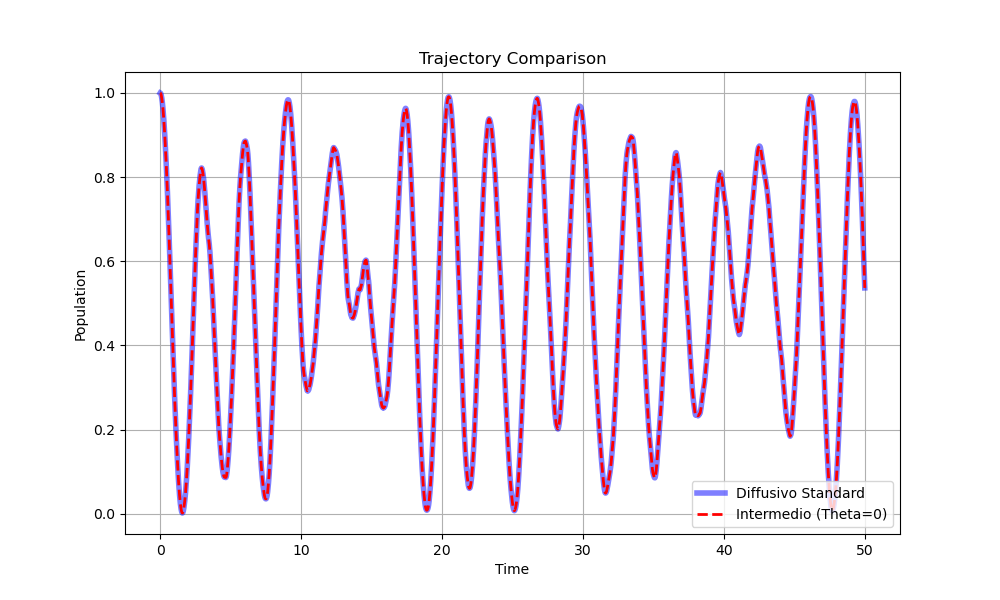

Maximum error between the two Dynamics: 1.24e-14
SUCCESS: The Dynamics are the same


In [17]:
# ---------------
# Comparison Plot
# ---------------
plt.figure(figsize=(10, 6))
# Plot solo la prima traiettoria per chiarezza
plt.plot(times, pop_std[:, 0], 'b-', linewidth=4, alpha=0.5, label='Diffusivo Standard')
plt.plot(times, pop_int[:, 0], 'r--', linewidth=2, label='Intermedio (Theta=0)')
plt.title("Trajectory Comparison")
plt.xlabel("Time")
plt.ylabel("Population")
plt.legend()
plt.grid()
plt.show()

# ----------------------
# Numerical Verification
# ----------------------
error = np.max(np.abs(pop_int - pop_std))
print(f"Maximum error between the two Dynamics: {error:.2e}")
if error < 1e-10:
    print("SUCCESS: The Dynamics are the same")
else:
    print("WARNING: there's differencies.")

## Comparison Trace Evolution

In [18]:
@njit
def partial_trace_manual(rho_tot, dim_sys, dim_anc):
    """
    Traccia parziale manuale compatibile con Numba.
    Traccia via l'ancilla (seconda parte del prodotto tensore).
    """
    # Reshape in (dim_sys, dim_anc, dim_sys, dim_anc)
    rho_reshaped = rho_tot.reshape(dim_sys, dim_anc, dim_sys, dim_anc)
    
    # Traccia manuale sugli indici dell'ancilla
    rho_sys = np.zeros((dim_sys, dim_sys), dtype=np.complex128)
    for i in range(dim_sys):
        for j in range(dim_sys):
            for k in range(dim_anc):
                rho_sys[i, j] += rho_reshaped[i, k, j, k]
    
    return rho_sys

In [19]:
@njit
def compute_trace_ancilla_core(rho_sys_initial, 
                              U_step_Cohe, U_step_Cohe_dag,       # Coherent Evolution Operator (theta=0)
                              U_step_Diff, U_step_Diff_dag,       # Diffusive Evolution Operator
                              rho_anc_Diff,          # Diffusive Ancilla
                              rho_anc_Cohe,          # Coherent Ancilla
                              dim_sys, dim_anc, projectors, n_times, N_site):
    """
    Complete evolution with H_sys + H_col: expand-evolve-trace at each time step.
    Corresponds to average over infinite trajectories.
    """
    # Arrays to store populations for all sites
    pops_complete_Diff = np.zeros((N_site, n_times), dtype=np.float64)
    pops_complete_Cohe = np.zeros((N_site, n_times), dtype=np.float64)
    
    # Initialize system state
    rho_sys_Diff = rho_sys_initial.copy()
    rho_sys_Cohe = rho_sys_initial.copy()
    
    # Initial populations
    for site in range(N_site):
        pops_complete_Diff[site, 0] = np.real(np.trace(projectors[site] @ rho_sys_Diff))
        pops_complete_Cohe[site, 0] = np.real(np.trace(projectors[site] @ rho_sys_Cohe))
    
    # Time Evolution
    for t in range(1, n_times):
        # =========
        # Diffusive
        # =========
        # 1: Expansion - kron with ancilla
        rho_tot_Diff = np.kron(rho_sys_Diff, rho_anc_Diff)
        
        # 2: Evolution - U_step contains H_sys + H_col
        rho_tot_Diff = U_step_Diff @ rho_tot_Diff @ U_step_Diff_dag
        
        # 3: Partial Trace - trace out ancilla
        rho_sys_Diff = partial_trace_manual(rho_tot_Diff, dim_sys, dim_anc)
        
        # ==================
        # Coherent (theta=0)
        # ==================
        # 1: Expansion
        rho_tot_Cohe = np.kron(rho_sys_Cohe, rho_anc_Cohe)
        
        # 2: Evolution
        rho_tot_Cohe = U_step_Cohe @ rho_tot_Cohe @ U_step_Cohe_dag
        
        # 3: Partial Trace
        rho_sys_Cohe = partial_trace_manual(rho_tot_Cohe, dim_sys, dim_anc)
        
        # 4: Store populations
        for site in range(N_site):
            pops_complete_Diff[site, t] = np.real(np.trace(projectors[site] @ rho_sys_Diff))
            pops_complete_Cohe[site, t] = np.real(np.trace(projectors[site] @ rho_sys_Cohe))
    
    return pops_complete_Diff, pops_complete_Cohe


def compute_trace_ancilla(rho_sys_initial, rho_anc_Diff, rho_anc_Cohe, 
                         U_step_Diff, U_step_Cohe, times, projectors, N_site):
    """
    Wrapper function to call Numba-compiled core.
    """
    # Times 
    n_times = len(times)
    
    # Dimensions
    dim_sys = rho_sys_initial.shape[0]
    dim_anc = rho_anc_Diff.shape[0]
    
    # Dagger operators
    U_step_Diff_dag = U_step_Diff.conj().T
    U_step_Cohe_dag = U_step_Cohe.conj().T
    
    # Call core function
    pops_complete_Diff, pops_complete_Cohe = compute_trace_ancilla_core(
        rho_sys_initial, 
        U_step_Cohe, U_step_Cohe_dag, 
        U_step_Diff, U_step_Diff_dag, 
        rho_anc_Diff, rho_anc_Cohe,          
        dim_sys, dim_anc, projectors, n_times, N_site)
    
    return pops_complete_Diff, pops_complete_Cohe

In [20]:
# ========================================
# Initial wave function and density matrix
# ========================================
# ------
# System
# ------
psi_sys_initial = tensor(basis(2, 0), basis(2, 1))  # Population only in site 2   
rho_sys_initial = (ket2dm(psi_sys_initial)).full()       

# ==================
# Theta parameters
# ==================
theta = 0.0  # Coherent regime
phi = theta - np.pi/2

# g parameters
g_z = np.cos(theta)    # = 1.0 for theta=0
g_x = np.sin(theta)    # = 0.0 for theta=0
g_0 = np.cos(phi/2)    # = 1/sqrt(2) for theta=0
g_1 = np.sin(phi/2)    # = -1/sqrt(2) for theta=0

print(f"theta = {theta:.4f} rad")
print(f"g_z = {g_z:.4f}, g_x = {g_x:.4f}")
print(f"g_0 = {g_0:.4f}, g_1 = {g_1:.4f}")

# -------
# Ancilla
# -------

# --- Diffusive ---
rho_anc_single_Diff = (qeye(2) / 2)  # Completely Mixed state I/2: [[0.5, 0], [0, 0.5]]
rho_anc_Diff = (tensor([rho_anc_single_Diff for _ in range(N_site)])).full()  # N ancillas

# --- Coherent (theta=0) ---
psi_anc_single_Cohe = (g_0 * basis(2, 0) + g_1 * basis(2, 1))
rho_anc_single_Cohe = ket2dm(psi_anc_single_Cohe)
rho_anc_Cohe = (tensor([rho_anc_single_Cohe for _ in range(N_site)])).full()  # N ancillas

# ==========
# Parameters
# ==========

# -------------------
# Dephasing Parameter
# -------------------
g_deph = 0.1       # Gamma rate

# --------------
# Lindblad Rates
# --------------
gamma_k = [g_deph, g_deph]

# ----------------------------------------------------------
# Scaling for the collsional algorithm c = sqrt(gamma / 4dt)
# ----------------------------------------------------------
c_CM = np.array([np.sqrt(g_deph / (4 * dt)) for _ in range(N_site)])  # same Coupling for the 2 sites

# =================
# H and U operators
# =================

# --- Coherent ---
H_sys_Cohe, H_int_Cohe, H_tot_Cohe = hamiltonian_N_ancillas_Cohe(N_site, E, V_array, c_CM, g_x, g_z) 

# Evolution operator for total Hamiltonian: U_step = exp(-i * H_tot * dt)
U_step_Cohe, _, _, _ = evolution_operator_Cohe(H_tot_Cohe, dt, method='diagonalization', hermitian=True)
U_step_Cohe = U_step_Cohe.full() if hasattr(U_step_Cohe, 'full') else U_step_Cohe.copy()

# --- Diffusive (same Hamiltonian, different ancilla state) ---
H_sys_Diff, H_int_Diff, H_tot_Diff = hamiltonian_N_ancillas_Diff(N_site, E, V_array, c_CM) 

# Evolution operator
U_step_Diff, _, _, _ = evolution_operator_Diff(H_tot_Diff, dt, method='diagonalization', hermitian=True)
U_step_Diff = U_step_Diff.full() if hasattr(U_step_Diff, 'full') else U_step_Diff.copy()

print(f"\nOperators computed:")
print(f"  U_step_Cohe shape: {U_step_Cohe.shape}")
print(f"  U_step_Diff shape: {U_step_Diff.shape}")
print(f"  rho_anc_Cohe shape: {rho_anc_Cohe.shape}")
print(f"  rho_anc_Diff shape: {rho_anc_Diff.shape}")

theta = 0.0000 rad
g_z = 1.0000, g_x = 0.0000
g_0 = 0.7071, g_1 = -0.7071

Operators computed:
  U_step_Cohe shape: (16, 16)
  U_step_Diff shape: (16, 16)
  rho_anc_Cohe shape: (4, 4)
  rho_anc_Diff shape: (4, 4)


In [21]:
print("Computation of the Complete Trace Evolution")
print("=" * 60)

# Complete evolution: expand-evolve-trace at each time step
pops_Diff, pops_Cohe = compute_trace_ancilla(rho_sys_initial, rho_anc_Diff, rho_anc_Cohe, U_step_Diff, 
                                            U_step_Cohe, times, projectors, N_site)

# Extract population for Site 2 (index 1)
pop_trace_Diff = pops_Diff[1, :]  # Site 2
pop_trace_Cohe = pops_Cohe[1, :]  # Site 2

print(f"Evolution computed for {n_steps} time steps")
print(f"Final population Site 2 - Diffusive: {pop_trace_Diff[-1]:.4f}")
print(f"Final population Site 2 - Coherent:  {pop_trace_Cohe[-1]:.4f}")

Computation of the Complete Trace Evolution
Evolution computed for 5000 time steps
Final population Site 2 - Diffusive: 0.5393
Final population Site 2 - Coherent:  0.5393


### Plot

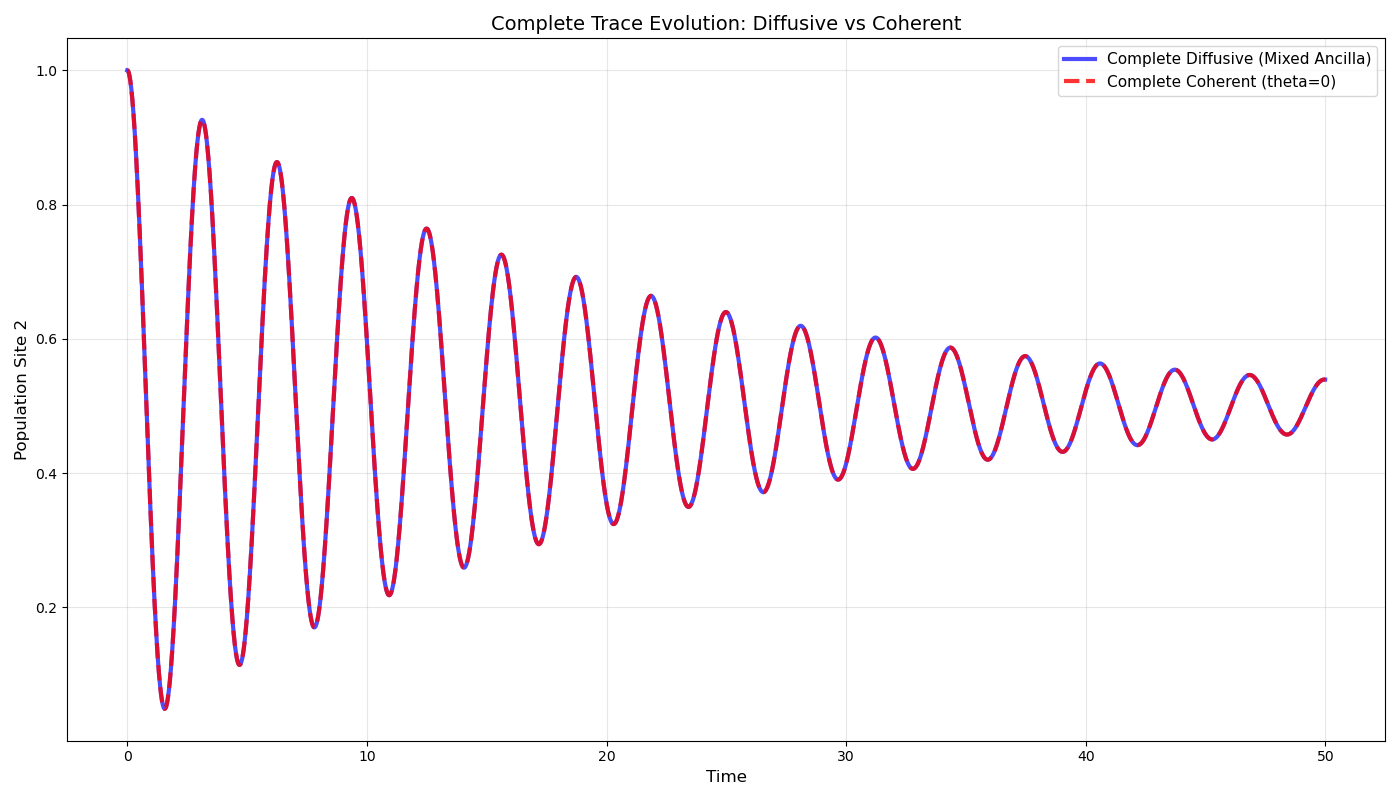


NUMERICAL COMPARISON
Max |Coherent - Diffusive|: 7.9936e-15

Total population (final time):
  Coherent:  1.000000 (should be ~1.0)
  Diffusive: 1.000000 (should be ~1.0)


In [22]:
plt.figure(figsize=(14, 8))

# Comparison: Diffusive vs Coherent Complete Trace Evolution
plt.plot(times, pop_trace_Diff, 'b-', linewidth=3, alpha=0.7, label='Complete Diffusive (Mixed Ancilla)')
plt.plot(times, pop_trace_Cohe, 'r--', linewidth=3, alpha=0.8, label='Complete Coherent (theta=0)')

plt.title("Complete Trace Evolution: Diffusive vs Coherent", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Population Site 2", fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =====================
# Numerical Verification
# =====================
print("\n" + "="*60)
print("NUMERICAL COMPARISON")
print("="*60)

# Difference between coherent and diffusive
diff_traces = np.max(np.abs(pop_trace_Cohe - pop_trace_Diff))
print(f"Max |Coherent - Diffusive|: {diff_traces:.4e}")

# Check if populations are normalized
norm_Cohe = pops_Cohe[:, -1].sum()
norm_Diff = pops_Diff[:, -1].sum()
print(f"\nTotal population (final time):")
print(f"  Coherent:  {norm_Cohe:.6f} (should be ~1.0)")
print(f"  Diffusive: {norm_Diff:.6f} (should be ~1.0)")

print("="*60)